# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

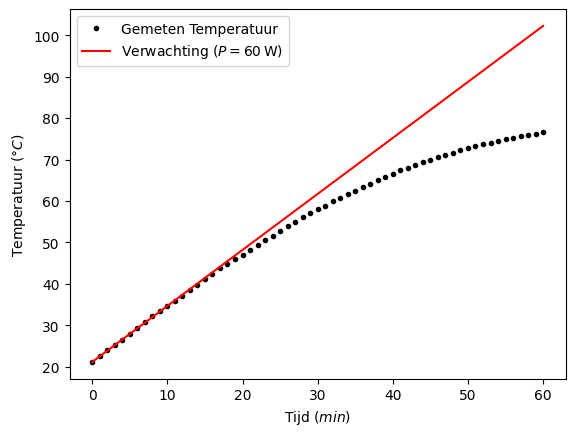

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = np.genfromtxt(r"C:\Users\minev\Documents\TU\IP2\Project\thermolab\tempmetingen.csv", delimiter= ';', skip_header=1 )
tijd = data[:,0]
temp = data[:,1]

m_maatbeker = 0.8208 # kg
m_start = 1.2929 # kg
m_eind = 1.2749 # kg
m_w_start = m_start - m_maatbeker      # Startmassa water (kg)
m_w_verdamp = m_start - m_eind  # Verdampt water (kg)
temp_start = data[0,1] # Gemeten starttemperatuur
temp_eind = data[-1,1]  # Gemeten eindtemperatuur
tijd_eind_min = 60
tijd_eind_s = tijd_eind_min * 60

c_water = 4186   # J/(kg*K)
c_glas = 840     # J/(kg*K) - Aanname voor de maatbeker (Pyrex)
L_v = 2.26e6     # J/kg - Latente warmte van verdamping (bij 100 °C)
P_verwarming = 60 # W

def T_verwacht(t_min):
    t_s = t_min * 60
    return temp_start + (P_verwarming * t_s) / ((m_w_start * c_water) + (m_maatbeker * c_glas))

temp_verwacht = T_verwacht(tijd)

plt.figure()
plt.plot(tijd, temp, 'k.', label='Gemeten Temperatuur')
plt.plot(tijd, temp_verwacht, 'r-', label=f'Verwachting ($P = {P_verwarming}\\,\\mathrm{{W}}$)')
plt.xlabel('Tijd $(min)$')
plt.ylabel('Temperatuur $(°C)$')
plt.legend()